In [1]:
from notebooks.models.utility import load_and_validate_final_data
from tauso.data.consts import INHIBITION

final_data, features = load_and_validate_final_data(version='oligo')

In [4]:
import pandas as pd
import numpy as np

train_df = final_data[final_data['split'] == 'train'].copy()
val_df   = final_data[final_data['split'] == 'val'].copy()
test_df  = final_data[final_data['split'] == 'test'].copy()

eval_group_col = 'custom_id'

X_train, y_train = train_df[features].values, train_df[INHIBITION].values
X_val, y_val     = val_df[features].values,   val_df[INHIBITION].values
X_test           = test_df[features].values

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(test_df)} | Features: {len(features)}")

# ---------------------------------------------------------
# 2. Build QID arrays for ranking objectives
# ---------------------------------------------------------
def build_qid_array(df, group_col):
    """Maps each group label to a contiguous integer ID, returns array aligned to df rows."""
    codes, _ = pd.factorize(df[group_col].values)
    return codes.astype(np.int32)

# XGBoost ranking requires rows sorted by qid
train_df_sorted = train_df.sort_values(eval_group_col)
val_df_sorted   = val_df.sort_values(eval_group_col)

X_train_rank, y_train_rank = train_df_sorted[features].values, train_df_sorted[INHIBITION].values
X_val_rank,   y_val_rank   = val_df_sorted[features].values,   val_df_sorted[INHIBITION].values

qid_train = build_qid_array(train_df_sorted, eval_group_col)
qid_val   = build_qid_array(val_df_sorted,   eval_group_col)

# ---------------------------------------------------------
# 3. Fast Spearman Setup (Pre-computing array indices)
# ---------------------------------------------------------
def precompute_eval_groups(df, y_true_arr, group_col):   # ← fixed: accept group_col
    groups = []
    # reset_index so positional indices match y_true_arr
    df_reset = df.reset_index(drop=True)
    for cohort, group in df_reset.groupby(group_col):    # ← fixed: was split_group
        if len(group) >= 20:
            groups.append((group.index.values, y_true_arr[group.index.values]))
    return groups

val_eval_groups  = precompute_eval_groups(val_df,  y_val,  eval_group_col)
test_eval_groups = precompute_eval_groups(test_df, test_df[INHIBITION].values, eval_group_col)


Train: 98113 | Val: 12018 | Test: 20828 | Features: 665


In [5]:
import xgboost as xgb
# ---------------------------------------------------------
# 4. Load data into DMatrix ONCE
# ---------------------------------------------------------
print("Loading data into GPU memory...")

dtrain_l2   = xgb.DMatrix(X_train,      label=y_train)
dval_l2     = xgb.DMatrix(X_val,        label=y_val)

dtrain_rank = xgb.DMatrix(X_train_rank, label=y_train_rank, qid=qid_train)
dval_rank   = xgb.DMatrix(X_val_rank,   label=y_val_rank,   qid=qid_val)

# Separate eval groups for the sorted val split used in ranking
val_eval_groups_rank = precompute_eval_groups(val_df_sorted, y_val_rank, eval_group_col)

print("Data loaded. Ready for trials.")

Loading data into GPU memory...
Data loaded. Ready for trials.


In [6]:
from scipy.stats import spearmanr
import optuna


# ---------------------------------------------------------
# 2. Optuna Objective Functions (Native API)
# ---------------------------------------------------------
def get_xgb_params(trial, objective):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'objective': objective,
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    if 'rank' in objective:
        params['ndcg_exp_gain'] = False

    return params


def calculate_fast_spearman(preds, eval_groups):
    spearmans = []
    for idxs, true_vals in eval_groups:
        corr, _ = spearmanr(true_vals, preds[idxs])
        if not np.isnan(corr):
            spearmans.append(corr)
    return np.nanmean(spearmans) if spearmans else 0.0


def objective_l2(trial):
    params = get_xgb_params(trial, 'reg:squarederror')
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    bst = xgb.train(
        params,
        dtrain_l2,
        num_boost_round=num_boost_round,
        evals=[(dval_l2, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds = bst.predict(dval_l2)
    return calculate_fast_spearman(preds, val_eval_groups)


def objective_ranking(trial, rank_objective):
    params = get_xgb_params(trial, rank_objective)
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    bst = xgb.train(
        params,
        dtrain_rank,
        num_boost_round=num_boost_round,
        evals=[(dval_rank, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds = bst.predict(dval_rank)
    return calculate_fast_spearman(preds, val_eval_groups_rank)  # ← only change


# ---------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------
N_TRIALS = 50

print("\nStarting L2 Regression Study...")
study_l2 = optuna.create_study(direction="maximize")
study_l2.optimize(objective_l2, n_trials=N_TRIALS, show_progress_bar=True)

df_results_l2 = study_l2.trials_dataframe()

[I 2026-04-13 12:13:44,868] A new study created in memory with name: no-name-d9db81f5-4a46-44ee-8107-5e53aa1b0eaf



Starting L2 Regression Study...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-13 12:13:47,371] Trial 0 finished with value: 0.4600901110530323 and parameters: {'max_depth': 9, 'learning_rate': 0.04944243990000063, 'subsample': 0.5001407517788548, 'colsample_bytree': 0.671623483387717, 'min_child_weight': 38, 'gamma': 8.795776729679159e-05, 'reg_alpha': 0.01972360638507492, 'reg_lambda': 3.209692400058501e-08, 'num_boost_round': 1000}. Best is trial 0 with value: 0.4600901110530323.
[I 2026-04-13 12:13:49,679] Trial 1 finished with value: 0.4849640730021093 and parameters: {'max_depth': 7, 'learning_rate': 0.028965286794363575, 'subsample': 0.954496211482158, 'colsample_bytree': 0.9198829837154724, 'min_child_weight': 34, 'gamma': 0.1008455274750509, 'reg_alpha': 0.3124637166922849, 'reg_lambda': 6.277988532338588e-05, 'num_boost_round': 900}. Best is trial 1 with value: 0.4849640730021093.
[I 2026-04-13 12:13:59,403] Trial 2 finished with value: 0.4802934446746588 and parameters: {'max_depth': 10, 'learning_rate': 0.027869874050751652, 'subsample': 0.

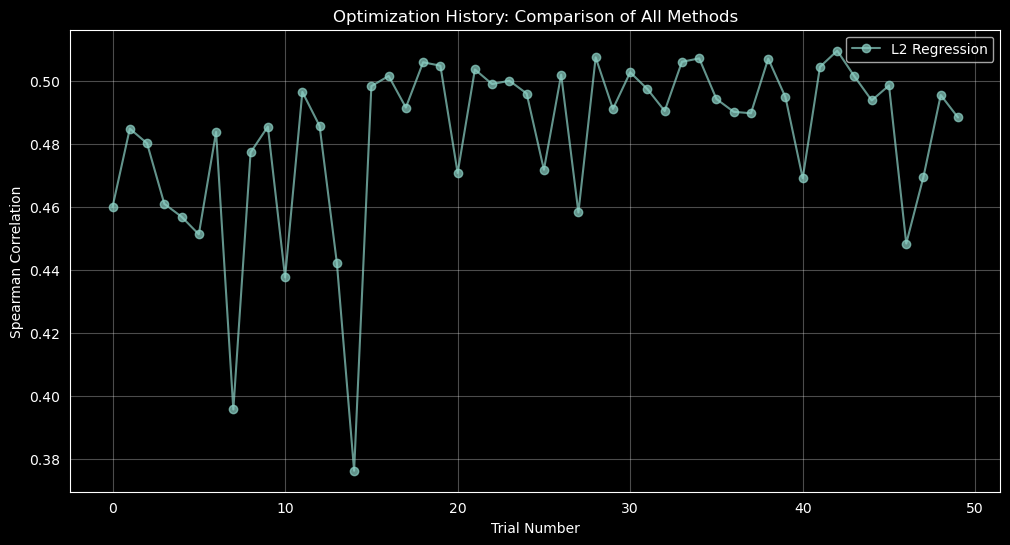


--- Evaluating L2 Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [12:24:31] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (L2 Model): 0.3408


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [12:24:33] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [7]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 5. Combined Plotting Function
# ---------------------------------------------------------
def plot_combined_history(df_dict):
    plt.figure(figsize=(12, 6))

    # Loop through the dictionary and plot each method's trial values
    for name, df in df_dict.items():
        # Using marker='o' and linestyle='-' to show the path of the trials
        plt.plot(df['number'], df['value'], marker='o', linestyle='-', alpha=0.7, label=name)

    plt.title("Optimization History: Comparison of All Methods")
    plt.xlabel("Trial Number")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Pass all results into the new combined plotting function
plot_combined_history({
    "L2 Regression": df_results_l2,
})

# ---------------------------------------------------------
# 6. Evaluate Utility on Final Test Set
# ---------------------------------------------------------
def evaluate_final_utility(study, objective, name):
    print(f"\n--- Evaluating {name} on Unseen Cell Lines (Test Set) ---")
    best_params = study.best_params
    best_params['tree_method'] = 'hist'
    best_params['device'] = 'cuda'
    best_params['objective'] = objective

    # FIXED: Ensure linear gain is applied for final evaluation on BOTH rankers
    if 'rank' in objective:
        best_params['ndcg_exp_gain'] = False

    if "reg" in objective:
        model = xgb.XGBRegressor(**best_params, random_state=42)
        model.fit(X_train, y_train)
    else:
        model = xgb.XGBRanker(**best_params, random_state=42)
        model.fit(X_train, y_train, qid=qid_train)

    preds = model.predict(X_test)
    final_spearman = calculate_fast_spearman(preds, test_eval_groups)

    print(f"Mean Spearman Correlation ({name}): {final_spearman:.4f}")
    return final_spearman

spearman_l2 = evaluate_final_utility(study_l2, 'reg:squarederror', "L2 Model")

In [8]:
from tauso.data.consts import *
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import cupy as cp

# --- SELECTION THRESHOLDS ---
PARSIMONY_TOLERANCE = 0.015
EARLY_STOP_DROP = 0.05
# ----------------------------

# --- GROUPING DEFINITIONS ---
EVAL_GROUP = 'custom_id'
# Update these column names to exactly match what's in your dataframe:
SELECT_GROUP = [CANONICAL_GENE, CELL_LINE]

# 1. Fast Tracking Functions & Setup
X_train_np, y_train_np = train_df[features].values, train_df[INHIBITION].values
X_val_np, y_val_np = val_df[features].values, val_df[INHIBITION].values
X_test_np, y_test_np = test_df[features].values, test_df[INHIBITION].values

print("Pinning datasets to RTX 5090 VRAM...")
X_train_gpu = cp.array(X_train_np)
y_train_gpu = cp.array(y_train_np)
X_val_gpu   = cp.array(X_val_np)
y_val_gpu   = cp.array(y_val_np)
X_test_gpu  = cp.array(X_test_np)
print("Data secured in VRAM.")

feat_to_idx = {feat: i for i, feat in enumerate(features)}

def get_large_cohort_indices(df, group_cols, min_size=50):
    # CRITICAL FIX: reset_index() ensures pandas indices match the 0-based NumPy rows
    df_reset = df.reset_index(drop=True)
    return [group.index.values for _, group in df_reset.groupby(group_cols) if len(group) >= min_size]

# Indices for EVALUATION (Reporting stats based on custom_id)
train_eval_idx = get_large_cohort_indices(train_df, EVAL_GROUP)
val_eval_idx   = get_large_cohort_indices(val_df, EVAL_GROUP)
test_eval_idx  = get_large_cohort_indices(test_df, EVAL_GROUP)

# Indices for SELECTION (Early stopping based on Canonical Gene x Cell Line)
val_select_idx = get_large_cohort_indices(val_df, SELECT_GROUP)

def calculate_metrics(preds, y_true, eval_groups):
    spearmans, top_1_means, top_5_means = [], [], []
    for idxs in eval_groups:
        t_vals = y_true[idxs]
        p_vals = preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr):
            spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))

        if k5 > 0:
            top5_idx = np.argpartition(p_vals, -k5)[-k5:]
            top_5_means.append(np.mean(t_vals[top5_idx]))
        if k1 > 0:
            top1_idx = np.argpartition(p_vals, -k1)[-k1:]
            top_1_means.append(np.mean(t_vals[top1_idx]))

    return {
        'spearman': np.nanmedian(spearmans) if spearmans else 0.0, # Changed to MEDIAN
        'top1_inhibition': np.nanmean(top_1_means) if top_1_means else 0.0,
        'top5_inhibition': np.nanmean(top_5_means) if top_5_means else 0.0
    }

# 2. Extract Best Optuna Parameters
best_l2_params = study_l2.best_params.copy()
best_l2_params.update({'tree_method': 'hist', 'device': 'cuda', 'objective': 'reg:squarederror'})
num_rounds = best_l2_params.pop('num_boost_round', best_l2_params.pop('n_estimators', 1000))

# 3. Execution Loop
current_features = list(features)
selection_history = []
max_spearman_seen = -1.0

total_iters = ((len(current_features) - 100) // 5) + 100 if len(current_features) > 100 else len(current_features)
pbar = tqdm(total=total_iters, desc="Dropping Features")

while len(current_features) > 0:
    curr_idxs = [feat_to_idx[f] for f in current_features]

    curr_X_train = X_train_gpu[:, curr_idxs]
    curr_X_val   = X_val_gpu[:, curr_idxs]
    curr_X_test  = X_test_gpu[:, curr_idxs]

    dtrain = xgb.QuantileDMatrix(curr_X_train, label=y_train_gpu, feature_names=current_features)
    dval   = xgb.QuantileDMatrix(curr_X_val, label=y_val_gpu, feature_names=current_features, ref=dtrain)

    bst = xgb.train(
        best_l2_params, dtrain, num_boost_round=num_rounds,
        evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False
    )

    preds_train = bst.inplace_predict(curr_X_train)
    preds_val   = bst.inplace_predict(curr_X_val)
    preds_test  = bst.inplace_predict(curr_X_test)

    if hasattr(preds_train, 'get'):
        preds_train = preds_train.get()
        preds_val = preds_val.get()
        preds_test = preds_test.get()

    # Calculate REPORTING metrics (custom_id)
    metrics_train = calculate_metrics(preds_train, y_train_np, train_eval_idx)
    metrics_val   = calculate_metrics(preds_val, y_val_np, val_eval_idx)
    metrics_test  = calculate_metrics(preds_test, y_test_np, test_eval_idx)

    # Calculate SELECTION metrics (canonical_gene x cell_line)
    metrics_selection = calculate_metrics(preds_val, y_val_np, val_select_idx)
    val_spear_select  = metrics_selection['spearman']

    if val_spear_select > max_spearman_seen:
        max_spearman_seen = val_spear_select

    step_data = {
        'num_features': len(current_features),
        'features_list': list(current_features),
        'train_spearman': metrics_train['spearman'],
        'train_top1': metrics_train['top1_inhibition'],
        'val_spearman': metrics_val['spearman'],       # Reporting (custom_id)
        'val_spearman_select': val_spear_select,       # Selection (gene x cell line)
        'test_spearman': metrics_test['spearman'],
        'test_top1': metrics_test['top1_inhibition']
    }

    # EARLY STOPPING CHECK (Based on Selection Metric)
    if val_spear_select < (max_spearman_seen - EARLY_STOP_DROP):
        print(f"\n[Early Stop] Selection Spearman dropped to {val_spear_select:.4f} (Peak: {max_spearman_seen:.4f}). Halting.")
        step_data['dropped_features'] = []
        selection_history.append(step_data)
        break

    if len(current_features) == 1:
        step_data['dropped_features'] = current_features
        selection_history.append(step_data)
        pbar.update(1)
        break

    imp_dict = bst.get_score(importance_type='gain')
    feat_importances = {f: imp_dict.get(f, 0.0) for f in current_features}
    sorted_feats = sorted(feat_importances.items(), key=lambda x: x[1])

    drop_n = 5 if len(current_features) > 100 else 1
    drop_n = min(drop_n, len(current_features) - 1)
    feats_to_drop = [x[0] for x in sorted_feats[:drop_n]]

    step_data['dropped_features'] = feats_to_drop
    selection_history.append(step_data)

    print(f"\n[Features: {len(current_features)} -> {len(current_features) - drop_n}]")
    print(f"  Eval (custom_id)       -> Val Spear: {metrics_val['spearman']:.4f} | Test Spear: {metrics_test['spearman']:.4f}")
    print(f"  Selection (Gene x Cell)-> Val Spear: {val_spear_select:.4f} (Peak: {max_spearman_seen:.4f})")

    current_features = [f for f in current_features if f not in feats_to_drop]
    pbar.update(1)

pbar.close()

# 4. PARSIMONIOUS SELECTION
df_backward_selection = pd.DataFrame(selection_history)

# Using the SELECTION metric to choose the best parsimonious model
absolute_peak = df_backward_selection['val_spearman_select'].max()
threshold = absolute_peak - PARSIMONY_TOLERANCE

candidates = df_backward_selection[df_backward_selection['val_spearman_select'] >= threshold]
best_row = candidates.loc[candidates['num_features'].idxmin()]
abs_peak_row = df_backward_selection.loc[df_backward_selection['val_spearman_select'].idxmax()]

print("\n" + "="*60)
print(f"🏆 OPTIMAL PARSIMONIOUS MODEL FOUND")
print("="*60)
print(f"Absolute Peak Selection Spear : {absolute_peak:.4f} (at {abs_peak_row['num_features']} features)")
print(f"Parsimonious Selection Spear  : {best_row['val_spearman_select']:.4f} (at {best_row['num_features']} features)")
print(f"Evaluation Test Spear (custom_id) : {best_row['test_spearman']:.4f}")
print(f"Evaluation Test Top 1% Inhib      : {best_row['test_top1']:.2f}")

NameError: name 'CANONICAL_GENE' is not defined

In [ ]:
# =========================================================
# 5. FINAL EVALUATION: OVERALL TEST SET & PSD3 SPECIFIC
# =========================================================

# 1. Extract the optimal features from your parsimonious selection
optimal_features = best_row['features_list']
opt_idxs = [feat_to_idx[f] for f in optimal_features]

# 2. Re-train a quick final model using ONLY the optimal features
print(f"\nTraining final model on the best {len(optimal_features)} features for Final Evaluation...")
final_X_train = X_train_gpu[:, opt_idxs]
final_dtrain  = xgb.QuantileDMatrix(final_X_train, label=y_train_gpu, feature_names=optimal_features)

final_bst = xgb.train(
    best_l2_params, final_dtrain, num_boost_round=num_rounds, verbose_eval=False
)

# ---------------------------------------------------------
# A. OVERALL TEST SET METRICS
# ---------------------------------------------------------
# Predict on the ENTIRE Test Set
final_X_test = X_test_gpu[:, opt_idxs]
test_preds = final_bst.inplace_predict(final_X_test)
if hasattr(test_preds, 'get'):
    test_preds = test_preds.get()

# Group by the variables without the n >= 50 rule to get true global medians
test_df_reset = test_df.reset_index(drop=True)
all_test_eval_idx   = [group.index.values for _, group in test_df_reset.groupby(EVAL_GROUP)]
all_test_select_idx = [group.index.values for _, group in test_df_reset.groupby(SELECT_GROUP)]

global_eval_metrics   = calculate_metrics(test_preds, y_test_np, all_test_eval_idx)
global_select_metrics = calculate_metrics(test_preds, y_test_np, all_test_select_idx)

print("\n" + "="*70)
print(f"🌍 OVERALL UNSEEN TEST SET PERFORMANCE")
print("="*70)
print(f"Total Test ASOs Tested : {len(test_df)}")
print(f"Median Spearman ({EVAL_GROUP}) : {global_eval_metrics['spearman']:.4f}")
print(f"Median Spearman ({SELECT_GROUP}) : {global_select_metrics['spearman']:.4f}")
print("="*70)

# ---------------------------------------------------------
# B. PSD3 GENE SPECIFIC BREAKDOWN
# ---------------------------------------------------------
psd3_mask = test_df[CANONICAL_GENE] == 'PSD3'
psd3_df = test_df[psd3_mask].reset_index(drop=True)

if len(psd3_df) == 0:
    print("⚠️ No data found for CANONICAL_GENE == 'PSD3' in the test set.")
else:
    psd3_X_np = psd3_df[optimal_features].values
    psd3_y_np = psd3_df[INHIBITION].values
    psd3_X_gpu = cp.array(psd3_X_np)

    psd3_preds = final_bst.inplace_predict(psd3_X_gpu)
    if hasattr(psd3_preds, 'get'):
        psd3_preds = psd3_preds.get()

    print("\n" + "="*70)
    print(f"🧬 PSD3 PERFORMANCE BROKEN DOWN BY {EVAL_GROUP.upper()}")
    print("="*70)

    # Loop through using the EVAL_GROUP variable
    for group_name, group in psd3_df.groupby(EVAL_GROUP):
        idxs = group.index.values
        t_vals = psd3_y_np[idxs]
        p_vals = psd3_preds[idxs]
        n_asos = len(idxs)

        # Calculate Spearman
        corr, _ = spearmanr(t_vals, p_vals)
        spear = corr if not np.isnan(corr) else 0.0

        # Calculate Top 1% and Top 5% indices
        k1 = max(1, int(n_asos * 0.01))
        k5 = max(1, int(n_asos * 0.05))

        top1_idx = np.argpartition(p_vals, -k1)[-k1:]
        top1_true_vals = t_vals[top1_idx]

        top5_idx = np.argpartition(p_vals, -k5)[-k5:]
        top5_true_vals = t_vals[top5_idx]

        # Compute Averages and Medians
        avg_top1 = np.mean(top1_true_vals)
        med_top1 = np.median(top1_true_vals)
        avg_top5 = np.mean(top5_true_vals)

        print(f"🔹 {EVAL_GROUP}: {group_name} (N = {n_asos} ASOs)")
        print(f"   ↳ Spearman Corr        : {spear:.4f}")
        print(f"   ↳ Avg Top 1% Inhib     : {avg_top1:.2f}")
        print(f"   ↳ Median Top 1% Inhib  : {med_top1:.2f}")
        print(f"   ↳ Avg Top 5% Inhib     : {avg_top5:.2f}")
        print("-" * 70)

In [ ]:
import matplotlib.pyplot as plt

# Retrieve optimal feature count for the marker line
opt_feat_count = best_row['num_features']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Spearman Correlation ---
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['train_spearman'], label='Train Spearman', color='blue', alpha=0.3)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['val_spearman'], label='Val Spearman', color='green', linewidth=2)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['test_spearman'], label='Test Spearman', color='purple', linewidth=2)
axes[0].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[0].invert_xaxis()
axes[0].set_title("Backward Selection: Spearman Correlation")
axes[0].set_xlabel("Number of Features Remaining")
axes[0].set_ylabel("Spearman Rank Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Top K Performance ---
# Showing Validation & Test Top 1% and 5% Mean Inhibitions
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top1'], label='Val Top 1% Inhib', color='green', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top5'], label='Val Top 5% Inhib', color='green', linestyle=':', alpha=0.7)
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top1'], label='Test Top 1% Inhib', color='purple', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top5'], label='Test Top 5% Inhib', color='purple', linestyle=':', alpha=0.7)
axes[1].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[1].invert_xaxis()
axes[1].set_title("Top K % Actual Inhibition (Higher is better)")
axes[1].set_xlabel("Number of Features Remaining")
axes[1].set_ylabel("Mean True Inhibition")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from tqdm.auto import tqdm

# Ensure optimal_features is defined from the backward selection step
optimal_features = best_row['features_list']

print(f"Training final GlobalModel with {len(optimal_features)} optimal features...")

# 1. Build Native DMatrices
opt_idxs = [feat_to_idx[f] for f in optimal_features]
dtrain_global = xgb.DMatrix(X_train_np[:, opt_idxs], label=y_train_np, feature_names=optimal_features)
dval_global = xgb.DMatrix(X_val_np[:, opt_idxs], label=y_val_np, feature_names=optimal_features)

# 2. Train Global Model
GlobalModel = xgb.train(
    best_l2_params,
    dtrain_global,
    num_boost_round=num_rounds,
    evals=[(dval_global, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# 3. Save to Disk
GlobalModel.save_model("GlobalModel2.json")
print("✅ Model saved successfully as 'GlobalModel.json'")

# 4. Extract Native XGBoost Gain
imp_gain = GlobalModel.get_score(importance_type='gain')
df_gain = pd.DataFrame(list(imp_gain.items()), columns=['Feature', 'Gain'])
df_gain = df_gain.sort_values(by='Gain', ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Group-Aware Permutation Importance
# ---------------------------------------------------------
print("\nCalculating Group-Aware Permutation Importance on Validation Set...")

baseline_preds = GlobalModel.predict(dval_global)
baseline_spearman = calculate_metrics(baseline_preds, y_val_np, val_eval_idx)['spearman']

df_eval = val_df[[split_group] + optimal_features].copy()
perm_results = []

for feature in tqdm(optimal_features, desc="Permuting Features"):
    X_shuffled_np = X_val_np[:, opt_idxs].copy()
    feat_idx_in_shuffled = optimal_features.index(feature)

    # Check if the feature is perfectly constant within every single cohort_id
    is_constant = df_eval.groupby(split_group)[feature].nunique().max() == 1

    if is_constant:
        # --- COHORT-LEVEL SWAP ---
        cohort_mapping = df_eval[[split_group, feature]].drop_duplicates().reset_index(drop=True)
        cohort_mapping['shuffled_val'] = np.random.permutation(cohort_mapping[feature].values)
        shuffled_col = df_eval[split_group].map(cohort_mapping.set_index(split_group)['shuffled_val'])

        X_shuffled_np[:, feat_idx_in_shuffled] = shuffled_col.values
        perm_type = "Cohort-Level"
    else:
        # --- ROW-LEVEL SWAP ---
        X_shuffled_np[:, feat_idx_in_shuffled] = np.random.permutation(X_shuffled_np[:, feat_idx_in_shuffled])
        perm_type = "Row-Level"

    dtemp = xgb.DMatrix(X_shuffled_np, feature_names=optimal_features)
    shuffled_preds = GlobalModel.predict(dtemp)
    shuffled_spearman = calculate_metrics(shuffled_preds, y_val_np, val_eval_idx)['spearman']

    perm_results.append({
        'Feature': feature,
        'Importance_Drop': baseline_spearman - shuffled_spearman,
        'Permutation_Type': perm_type
    })

df_perm = pd.DataFrame(perm_results)

# Split into the two distinct tracking DataFrames
df_perm_cohort = df_perm[df_perm['Permutation_Type'] == 'Cohort-Level'].sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)
df_perm_row = df_perm[df_perm['Permutation_Type'] == 'Row-Level'].sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
TOP_N = 20

# --- Plot 1: XGBoost Gain ---
sns.barplot(x='Gain', y='Feature', data=df_gain.head(TOP_N), ax=axes[0], palette='viridis')
axes[0].set_title(f"Top {TOP_N}: XGBoost Information Gain", fontsize=14)
axes[0].set_xlabel("Gain")
axes[0].set_ylabel("")

# --- Plot 2: Cohort-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_cohort.head(TOP_N), ax=axes[1], palette='flare')
axes[1].set_title(f"Top {TOP_N}: Cohort-Level Permutation", fontsize=14)
axes[1].set_xlabel("Spearman Drop")
axes[1].set_ylabel("")

# --- Plot 3: Row-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_row.head(TOP_N), ax=axes[2], palette='crest')
axes[2].set_title(f"Top {TOP_N}: Row-Level Permutation", fontsize=14)
axes[2].set_xlabel("Spearman Drop")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print Exhaustive Descending Lists
# ---------------------------------------------------------
print("\n" + "="*60)
print("ALL FEATURES: NATIVE XGBOOST GAIN")
print("="*60)
print(df_gain.to_string(index=False))

print("\n" + "="*60)
print("ALL FEATURES: COHORT-LEVEL PERMUTATION IMPORTANCE")
print("(Features constant across a cohort)")
print("="*60)
print(df_perm_cohort[['Feature', 'Importance_Drop']].to_string(index=False))

print("\n" + "="*60)
print("ALL FEATURES: ROW-LEVEL PERMUTATION IMPORTANCE")
print("(Features that vary within a cohort)")
print("="*60)
print(df_perm_row[['Feature', 'Importance_Drop']].to_string(index=False))

In [ ]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# Top 20 Features to plot
TOP_N = 20

# --- Plot 1: Native XGBoost Gain ---
sns.barplot(
    x='Gain', y='Feature',
    data=df_gain.head(TOP_N),
    ax=axes[0], palette='viridis'
)
axes[0].set_title(f"Top {TOP_N} Features by Native XGBoost Gain", fontsize=14)
axes[0].set_xlabel("Information Gain")
axes[0].set_ylabel("")

# --- Plot 2: Permutation Importance ---
# We use 'hue' to color-code whether the feature was swapped by Cohort or Row
sns.barplot(
    x='Importance_Drop', y='Feature',
    hue='Permutation_Type', dodge=False,
    data=df_perm.head(TOP_N),
    ax=axes[1], palette={'Cohort-Level': '#e74c3c', 'Row-Level': '#3498db'}
)
axes[1].set_title(f"Top {TOP_N} Features by Group-Aware Permutation Importance", fontsize=14)
axes[1].set_xlabel("Drop in Validation Spearman")
axes[1].set_ylabel("")
axes[1].legend(title="Permutation Strategy", loc="lower right")

plt.tight_layout()
plt.show()

# Print summary of the top features
print("\n--- Top 10 Most Critical Features (Permutation) ---")
print(df_perm.head(10).to_string(index=False))